# Kalshi Window Explorer

Connects to `~/.btc_windows.db` written by `btc_recorder.py`.

Records yes/no ask ticks every second for BTC, ETH, SOL, XRP 15-min windows.

In [128]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DB = Path.home() / ".btc_windows.db"
con = sqlite3.connect(DB)
print(f"Connected: {DB}")

Connected: /Users/Harish/.btc_windows.db


## All Windows

In [129]:
pd.read_sql("""
    SELECT id, ticker,
           datetime(window_start_ts, 'unixepoch', 'localtime') AS time_local,
           floor_strike, winner,
           (SELECT COUNT(*) FROM ticks WHERE window_id = windows.id) AS tick_count
    FROM windows
    ORDER BY window_start_ts DESC
""", con)

,id,ticker,time_local,floor_strike,winner,tick_count
0,121,KXXRP15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,126
1,120,KXSOL15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,126
2,119,KXETH15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,126
3,118,KXBTC15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,126
4,117,KXXRP15M-26APR071515-15,2026-04-07 15:00:00,NaN,yes,896
...,...,...,...,...,...,...
115,6,KXBTC15M-26APR070830-30,2026-04-07 08:15:00,NaN,yes,897
116,5,KXXRP15M-26APR070815-15,2026-04-07 08:00:00,1.3065,no,84
117,4,KXSOL15M-26APR070815-15,2026-04-07 08:00:00,79.2198,no,84
118,3,KXETH15M-26APR070815-15,2026-04-07 08:00:00,2089.6100,no,84


## Load & Plot a Window

In [130]:
# Set TICKER to a specific ticker string, or leave None to use the latest window
TICKER = None   # e.g. "KXBTC15M-26APR071500-00"

if TICKER:
    df = pd.read_sql("""
        SELECT t.elapsed_sec, t.yes_ask, t.no_ask
        FROM ticks t JOIN windows w ON w.id = t.window_id
        WHERE w.ticker = ?
        ORDER BY t.elapsed_sec
    """, con, params=(TICKER,))
else:
    df = pd.read_sql("""
        SELECT t.elapsed_sec, t.yes_ask, t.no_ask
        FROM ticks t
        JOIN windows w ON w.id = t.window_id
        WHERE w.id = (SELECT MAX(id) FROM windows)
        ORDER BY t.elapsed_sec
    """, con)
    TICKER = pd.read_sql("SELECT ticker FROM windows ORDER BY id DESC LIMIT 1", con).iloc[0, 0]

df = df.set_index("elapsed_sec")
print(f"{TICKER}  —  {len(df)} ticks")
print(f"YES  min={df.yes_ask.min():.2f}  max={df.yes_ask.max():.2f}  avg={df.yes_ask.mean():.2f}")
print(f"NO   min={df.no_ask.min():.2f}   max={df.no_ask.max():.2f}   avg={df.no_ask.mean():.2f}")
df.head()

KXXRP15M-26APR071530-30  —  126 ticks
YES  min=0.55  max=0.86  avg=0.69
NO   min=0.20   max=0.86   avg=0.40


,yes_ask,no_ask
elapsed_sec,,
1,0.86,0.86
2,0.67,0.67
3,0.55,0.67
4,0.55,0.67
5,0.55,0.67


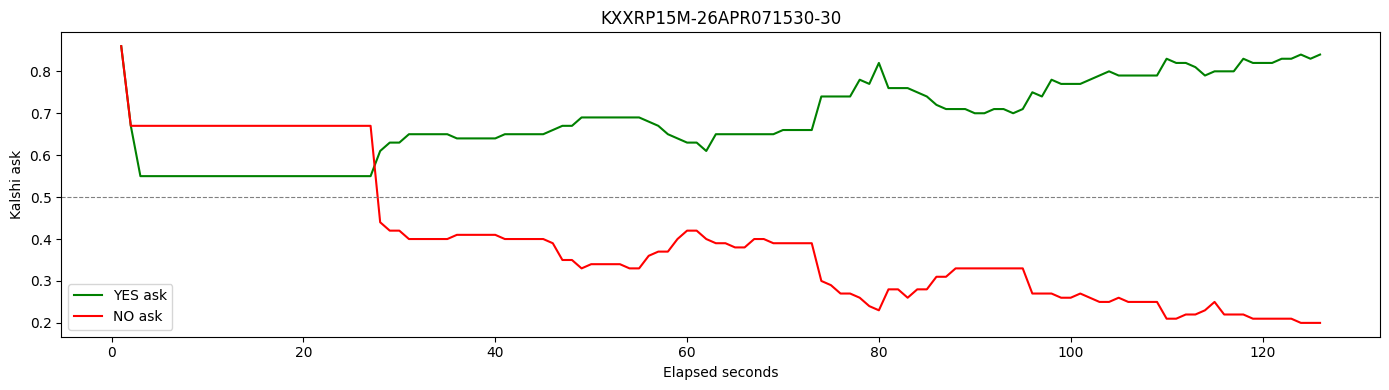

In [131]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["yes_ask"], color="green", label="YES ask")
ax.plot(df.index, df["no_ask"],  color="red",   label="NO ask")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Elapsed seconds")
ax.set_ylabel("Kalshi ask")
ax.set_title(TICKER)
ax.legend()
plt.tight_layout()
plt.show()

## All Resolved Windows — Summary

In [132]:
pd.read_sql("""
    SELECT w.ticker,
           datetime(w.window_start_ts, 'unixepoch', 'localtime') AS time_local,
           w.floor_strike, w.winner,
           COUNT(t.id)    AS ticks,
           AVG(t.yes_ask) AS avg_yes,
           AVG(t.no_ask)  AS avg_no,
           MIN(t.yes_ask) AS min_yes,
           MAX(t.yes_ask) AS max_yes
    FROM windows w
    LEFT JOIN ticks t ON t.window_id = w.id
    GROUP BY w.id
    ORDER BY w.window_start_ts DESC
""", con)

,ticker,time_local,floor_strike,winner,ticks,avg_yes,avg_no,min_yes,max_yes
0,KXBTC15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,127,0.646142,0.368110,0.520,0.810
1,KXETH15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,127,0.672913,0.371811,0.550,0.830
2,KXSOL15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,127,0.730787,0.331575,0.500,0.900
3,KXXRP15M-26APR071530-30,2026-04-07 15:15:00,NaN,NaN,127,0.686850,0.394094,0.550,0.860
4,KXBTC15M-26APR071515-15,2026-04-07 15:00:00,68427.6300,yes,896,0.475544,0.540551,0.180,1.000
...,...,...,...,...,...,...,...,...,...
115,KXXRP15M-26APR070830-30,2026-04-07 08:15:00,NaN,yes,897,0.800929,0.228068,0.390,0.999
116,KXBTC15M-26APR070815-15,2026-04-07 08:00:00,68351.1100,no,84,0.004434,0.996276,0.001,0.015
117,KXETH15M-26APR070815-15,2026-04-07 08:00:00,2089.6100,no,84,0.003687,0.999000,0.002,0.005
118,KXSOL15M-26APR070815-15,2026-04-07 08:00:00,79.2198,no,84,0.001976,0.999000,0.001,0.004


## NumPy Matrix — All Windows (for stumpy)

In [133]:
def load_series(ticker: str, col: str = "yes_ask") -> np.ndarray:
    """Load one window as a 900-point float array, forward-filling gaps."""
    d = pd.read_sql("""
        SELECT t.elapsed_sec, t.yes_ask, t.no_ask
        FROM ticks t JOIN windows w ON w.id = t.window_id
        WHERE w.ticker = ?
        ORDER BY t.elapsed_sec
    """, con, params=(ticker,))
    return (d.set_index("elapsed_sec")
             .reindex(range(900))
             .ffill()
             .bfill()[col]
             .to_numpy(dtype=np.float64))

# Load all resolved windows
meta = pd.read_sql(
    "SELECT ticker, winner FROM windows WHERE winner IS NOT NULL ORDER BY window_start_ts",
    con
)

if len(meta):
    matrix = np.vstack([load_series(t) for t in meta["ticker"]])
    print(f"Matrix: {matrix.shape}  ({len(meta)} resolved windows × 900s)")
    print(meta["winner"].value_counts().to_string())
else:
    print("No resolved windows yet — keep btc_recorder.py running through at least one full 15-min window")

Matrix: (116, 900)  (116 resolved windows × 900s)
winner
no     68
yes    48


## Symbol Divergence — When Did Coins End Differently?

In [134]:
# Extract coin symbol from ticker prefix (KXBTC15M-... → BTC)
SERIES = {"KXBTC15M": "BTC", "KXETH15M": "ETH", "KXSOL15M": "SOL", "KXXRP15M": "XRP"}

windows = pd.read_sql(
    "SELECT ticker, window_start_ts, winner FROM windows WHERE winner IS NOT NULL",
    con
)
windows["sym"] = windows["ticker"].str[:8].map(SERIES)
windows = windows.dropna(subset=["sym"])

# Pivot: one row per window_start_ts, one column per coin
pivot = (
    windows
    .pivot(index="window_start_ts", columns="sym", values="winner")
    .rename_axis(None, axis=1)
    .reset_index()
)
pivot["time_local"] = pd.to_datetime(pivot["window_start_ts"], unit="s").dt.tz_localize("UTC").dt.tz_convert("America/New_York")

# Only keep rows where all 4 coins have a result
syms = [s for s in ["BTC", "ETH", "SOL", "XRP"] if s in pivot.columns]
full = pivot.dropna(subset=syms).copy()

# Flag windows where coins diverge (not all the same outcome)
full["all_same"]  = full[syms].nunique(axis=1) == 1
full["diverged"]  = ~full["all_same"]

total    = len(full)
diverged = full["diverged"].sum()
agreed   = full["all_same"].sum()

print(f"Windows with all 4 coins resolved : {total}")
print(f"  All same outcome                : {agreed}  ({agreed/total*100:.1f}%)")
print(f"  At least one diverged           : {diverged}  ({diverged/total*100:.1f}%)")
print()

# Show the diverged windows
cols = ["time_local"] + syms
full[cols].where(full["diverged"]).dropna(how="all").sort_values("time_local", ascending=False)

Windows with all 4 coins resolved : 29
  All same outcome                : 20  (69.0%)
  At least one diverged           : 9  (31.0%)



,time_local,BTC,ETH,SOL,XRP
27,2026-04-07 14:45:00-04:00,no,no,yes,no
24,2026-04-07 14:00:00-04:00,no,no,yes,yes
23,2026-04-07 13:45:00-04:00,no,yes,no,no
20,2026-04-07 13:00:00-04:00,yes,no,no,no
18,2026-04-07 12:30:00-04:00,no,yes,yes,yes
16,2026-04-07 12:00:00-04:00,no,no,no,yes
15,2026-04-07 11:45:00-04:00,yes,yes,yes,no
6,2026-04-07 09:30:00-04:00,no,no,yes,no
4,2026-04-07 09:00:00-04:00,yes,yes,no,yes


In [135]:
# Per-pair divergence counts — which pairs disagree most often?
from itertools import combinations

rows = []
for a, b in combinations(syms, 2):
    sub = full[[a, b]].dropna()
    diff = (sub[a] != sub[b]).sum()
    rows.append({"pair": f"{a} vs {b}", "diverged": diff,
                 "total": len(sub), "diverge_%": round(diff / len(sub) * 100, 1) if len(sub) else 0})

pd.DataFrame(rows).sort_values("diverged", ascending=False)

,pair,diverged,total,diverge_%
1,BTC vs SOL,6,29,20.7
2,BTC vs XRP,5,29,17.2
3,ETH vs SOL,5,29,17.2
5,SOL vs XRP,5,29,17.2
4,ETH vs XRP,4,29,13.8
0,BTC vs ETH,3,29,10.3


## Cross-Coin Arb Scan — high + low < 0.95 per second

In [141]:
from itertools import combinations

# SERIES    = {"KXBTC15M": "BTC", "KXETH15M": "ETH", "KXXRP15M": "XRP"}   # SOL excluded
SERIES = {"KXBTC15M": "BTC", "KXETH15M": "ETH", "KXSOL15M": "SOL", "KXXRP15M": "XRP"}
THRESHOLD = 0.95

all_ticks = pd.read_sql("""
    SELECT t.elapsed_sec, t.yes_ask, t.no_ask,
           w.ticker, w.winner, w.window_start_ts
    FROM ticks t
    JOIN windows w ON w.id = t.window_id
    WHERE w.winner IS NOT NULL
      AND t.yes_ask IS NOT NULL AND t.no_ask IS NOT NULL
""", con)

all_ticks["sym"]       = all_ticks["ticker"].str[:8].map(SERIES)
all_ticks["high"]      = all_ticks[["yes_ask","no_ask"]].max(axis=1)
all_ticks["low"]       = all_ticks[["yes_ask","no_ask"]].min(axis=1)
all_ticks["high_side"] = np.where(all_ticks["yes_ask"] >= all_ticks["no_ask"], "yes", "no")
all_ticks = all_ticks.dropna(subset=["sym"])

wide = all_ticks.pivot_table(
    index=["window_start_ts","elapsed_sec"], columns="sym",
    values=["high","low","high_side","winner"], aggfunc="first"
)
wide.columns = ["_".join(c) for c in wide.columns]
wide = wide.reset_index()

syms = [s for s in ["BTC","ETH","XRP"] if f"high_{s}" in wide.columns]

hs_cols = [f"high_side_{s}" for s in syms]
wide["all_yes"] = (wide[hs_cols] == "yes").all(axis=1)
wide["all_no"]  = (wide[hs_cols] == "no").all(axis=1)
wide = wide[wide["all_yes"] | wide["all_no"]].copy()

print(f"Aligned seconds: {len(wide):,}  (all-YES={wide['all_yes'].sum():,}  all-NO={wide['all_no'].sum():,})")

rows = []
for a, b in combinations(syms, 2):
    sub = wide[["window_start_ts","elapsed_sec",
                f"high_{a}",f"low_{a}",f"high_side_{a}",f"winner_{a}",
                f"high_{b}",f"low_{b}",f"high_side_{b}",f"winner_{b}"]].dropna()
    for x, y in [(a, b), (b, a)]:
        hit = sub[(sub[f"high_{x}"] + sub[f"low_{y}"]) < THRESHOLD].copy()
        if hit.empty:
            continue
        hit["pair"]      = f"{x} hi + {y} lo"
        hit["x_val"]     = hit[f"high_{x}"]
        hit["y_val"]     = hit[f"low_{y}"]
        hit["cost"]      = hit[f"high_{x}"] + hit[f"low_{y}"]
        hit["high_side"] = hit[f"high_side_{x}"]
        hit["winner_x"]  = hit[f"winner_{x}"]
        hit["winner_y"]  = hit[f"winner_{y}"]
        hit["same_end"]  = hit[f"winner_{x}"] == hit[f"winner_{y}"]
        hit["profit"]    = np.where(hit["same_end"], 1 - hit["cost"], -hit["cost"])
        hit["_x"] = x; hit["_y"] = y
        rows.append(hit[["window_start_ts","elapsed_sec","pair","_x","_y",
                          "x_val","y_val","cost","high_side",
                          "winner_x","winner_y","same_end","profit"]])

all_hits = pd.concat(rows).sort_values(["window_start_ts","pair","elapsed_sec"]).reset_index(drop=True)
all_hits["gap"]     = all_hits.groupby(["window_start_ts","pair"])["elapsed_sec"].diff().fillna(1)
all_hits["new_run"] = all_hits["gap"] > 1
all_hits["run_id"]  = all_hits.groupby(["window_start_ts","pair"])["new_run"].cumsum()

def best_row(g):
    idx = g["cost"].idxmin()
    return pd.Series({
        "entry_t":   g["elapsed_sec"].min(),
        "exit_t":    g["elapsed_sec"].max(),
        "n_seconds": len(g),
        "best_cost": g.loc[idx, "cost"],
        "hi_val":    g.loc[idx, "x_val"],
        "lo_val":    g.loc[idx, "y_val"],
        "coin_hi":   g["_x"].iloc[0],
        "coin_lo":   g["_y"].iloc[0],
        "high_side": g["high_side"].iloc[0],
        "same_end":  g["same_end"].iloc[0],
        "winner_x":  g["winner_x"].iloc[0],
        "winner_y":  g["winner_y"].iloc[0],
    })

summary = all_hits.groupby(["window_start_ts","pair","run_id"]).apply(best_row).reset_index()
summary["profit"]     = np.where(summary["same_end"], 1 - summary["best_cost"], -summary["best_cost"])
summary["time_local"] = (
    pd.to_datetime(summary["window_start_ts"], unit="s")
    .dt.tz_localize("UTC").dt.tz_convert("America/New_York")
    .dt.strftime("%m/%d %H:%M")
)

n     = len(summary)
same  = summary["same_end"].sum()
avg_p = summary["profit"].mean()
win_p = summary[summary["same_end"]]["profit"].mean()
los_p = summary[~summary["same_end"]]["profit"].mean() if (~summary["same_end"]).any() else 0

print(f"\nTotal opportunities (consecutive runs): {n}")
print(f"  Same side ended  : {same} / {n}  ({same/n*100:.1f}%)")
print(f"  Avg profit/trade : ${avg_p:.3f}   (win=${win_p:.3f}  lose=${los_p:.3f})")
print()

summary[["time_local","pair","run_id","entry_t","exit_t","n_seconds",
         "coin_hi","hi_val","coin_lo","lo_val","best_cost",
         "high_side","same_end","winner_x","winner_y","profit"]]\
    .sort_values(["time_local","pair","entry_t"])

Aligned seconds: 17,156  (all-YES=8,733  all-NO=8,423)

Total opportunities (consecutive runs): 1432
  Same side ended  : 1283 / 1432  (89.6%)
  Avg profit/trade : $0.021   (win=$0.124  lose=$-0.861)



,time_local,pair,run_id,entry_t,exit_t,n_seconds,coin_hi,hi_val,coin_lo,lo_val,best_cost,high_side,same_end,winner_x,winner_y,profit
0,04/07 08:15,BTC hi + ETH lo,0,47,50,4,BTC,0.61,ETH,0.29,0.90,no,True,yes,yes,0.10
1,04/07 08:15,BTC hi + ETH lo,1,54,56,3,BTC,0.60,ETH,0.30,0.90,no,True,yes,yes,0.10
2,04/07 08:15,BTC hi + ETH lo,2,59,64,6,BTC,0.58,ETH,0.32,0.90,no,True,yes,yes,0.10
3,04/07 08:15,BTC hi + ETH lo,3,66,84,19,BTC,0.59,ETH,0.31,0.90,no,True,yes,yes,0.10
4,04/07 08:15,BTC hi + ETH lo,4,87,89,3,BTC,0.64,ETH,0.29,0.93,no,True,yes,yes,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1427,04/07 15:00,XRP hi + BTC lo,0,68,69,2,XRP,0.54,BTC,0.40,0.94,no,True,yes,yes,0.06
1428,04/07 15:00,XRP hi + BTC lo,1,75,90,16,XRP,0.54,BTC,0.37,0.91,no,True,yes,yes,0.09
1429,04/07 15:00,XRP hi + BTC lo,2,97,103,7,XRP,0.52,BTC,0.37,0.89,no,True,yes,yes,0.11
1430,04/07 15:00,XRP hi + BTC lo,3,105,113,9,XRP,0.55,BTC,0.38,0.93,no,True,yes,yes,0.07


## Limit Order Sizing — hi+1¢ / lo fills within budget

In [137]:
# ── Parameters ───────────────────────────────────────────────────────────────
THRESHOLD = 0.85   # only enter when hi+lo < this
MAX_COST  = 0.90   # absolute max combined cost willing to pay
SHARES    = 10     # same share count on both legs

# ── Compute limit prices for each opportunity ─────────────────────────────────
# hi_limit: 1c above current ask → ensures fill, slight priority
# lo_limit: whatever budget remains after hi, minus 1c buffer
opp = summary[summary["best_cost"] < THRESHOLD].copy()

opp["hi_limit"]     = (opp["hi_val"] + 0.01).round(2)
opp["lo_limit"]     = (MAX_COST - opp["hi_limit"] - 0.01).round(2)
opp["combined_max"] = (opp["hi_limit"] + opp["lo_limit"]).round(2)

# Actual fill price ≈ current market (we post above ask so fills at ask)
# Profit if same_end: $1 - actual fill cost per share
opp["fill_cost"]    = (opp["hi_val"] + opp["lo_val"]).round(2)   # what we actually pay
opp["profit_net"]   = np.where(opp["same_end"], 1 - opp["fill_cost"], -opp["fill_cost"])
opp["dollar_pnl"]   = opp["profit_net"] * SHARES

# Sanity check: lo_limit must be > lo_val (otherwise no room to post above)
opp["lo_has_room"]  = opp["lo_limit"] > opp["lo_val"]
opp["valid"]        = opp["lo_has_room"] & (opp["combined_max"] <= MAX_COST)

n     = len(opp)
valid = opp["valid"].sum()
same  = opp[opp["valid"]]["same_end"].sum()
total_pnl = opp[opp["valid"]]["dollar_pnl"].sum()

print(f"Opportunities with hi+lo < {THRESHOLD}: {n}")
print(f"  Valid (lo_limit > lo_val, combined <= {MAX_COST}): {valid}")
print(f"  Same side ended : {same} / {valid}  ({same/valid*100:.1f}% if valid else 0)")
print(f"  Total P&L @ {SHARES} shares : ${total_pnl:.2f}")
print()

opp[opp["valid"]][
    ["time_local","pair","entry_t","n_seconds",
     "coin_hi","hi_val","hi_limit",
     "coin_lo","lo_val","lo_limit",
     "combined_max","fill_cost",
     "high_side","same_end","winner_x","winner_y",
     "profit_net","dollar_pnl"]
].sort_values(["time_local","entry_t"])

Opportunities with hi+lo < 0.85: 337
  Valid (lo_limit > lo_val, combined <= 0.9): 337
  Same side ended : 298 / 337  (88.4% if valid else 0)
  Total P&L @ 10 shares : $506.80



,time_local,pair,entry_t,n_seconds,coin_hi,hi_val,hi_limit,coin_lo,lo_val,lo_limit,combined_max,fill_cost,high_side,same_end,winner_x,winner_y,profit_net,dollar_pnl
40,04/07 08:15,ETH hi + XRP lo,233,7,ETH,0.52,0.53,XRP,0.270,0.36,0.89,0.79,yes,True,yes,yes,0.21,2.1
41,04/07 08:15,ETH hi + XRP lo,242,2,ETH,0.53,0.54,XRP,0.270,0.35,0.89,0.80,yes,True,yes,yes,0.20,2.0
42,04/07 08:15,ETH hi + XRP lo,245,35,ETH,0.55,0.56,XRP,0.250,0.33,0.89,0.80,yes,True,yes,yes,0.20,2.0
43,04/07 08:15,ETH hi + XRP lo,283,1,ETH,0.54,0.55,XRP,0.280,0.34,0.89,0.82,yes,True,yes,yes,0.18,1.8
28,04/07 08:15,ETH hi + BTC lo,417,3,ETH,0.54,0.55,BTC,0.230,0.34,0.89,0.77,yes,True,yes,yes,0.23,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1401,04/07 15:00,BTC hi + XRP lo,812,14,BTC,0.52,0.53,XRP,0.009,0.36,0.89,0.53,yes,True,yes,yes,0.47,4.7
1380,04/07 15:00,BTC hi + ETH lo,846,1,BTC,0.53,0.54,ETH,0.230,0.35,0.89,0.76,yes,True,yes,yes,0.24,2.4
1402,04/07 15:00,BTC hi + XRP lo,846,1,BTC,0.53,0.54,XRP,0.009,0.35,0.89,0.54,yes,True,yes,yes,0.46,4.6
1403,04/07 15:00,BTC hi + XRP lo,848,16,BTC,0.71,0.72,XRP,0.008,0.17,0.89,0.72,yes,True,yes,yes,0.28,2.8


## Stumpy Live Match — Current Window vs Past Top 3

Current window start: 15:15  elapsed T=674s

BTC  (current window t=0..674)
  Rank  Time             Outcome     Dist  Votes
  #1    04-07 13:00          YES   12.114
  #2    04-07 13:30          YES   13.920
  #3    04-07 09:00          YES   16.274
  #4    04-07 11:15          YES   17.180
  #5    04-07 08:15          YES   18.478
  → Stumpy vote: YES  (YES=5 NO=0)
  Current odds  t=674s  YES=0.99  NO=0.01  → market says YES


IndexError: list index out of range

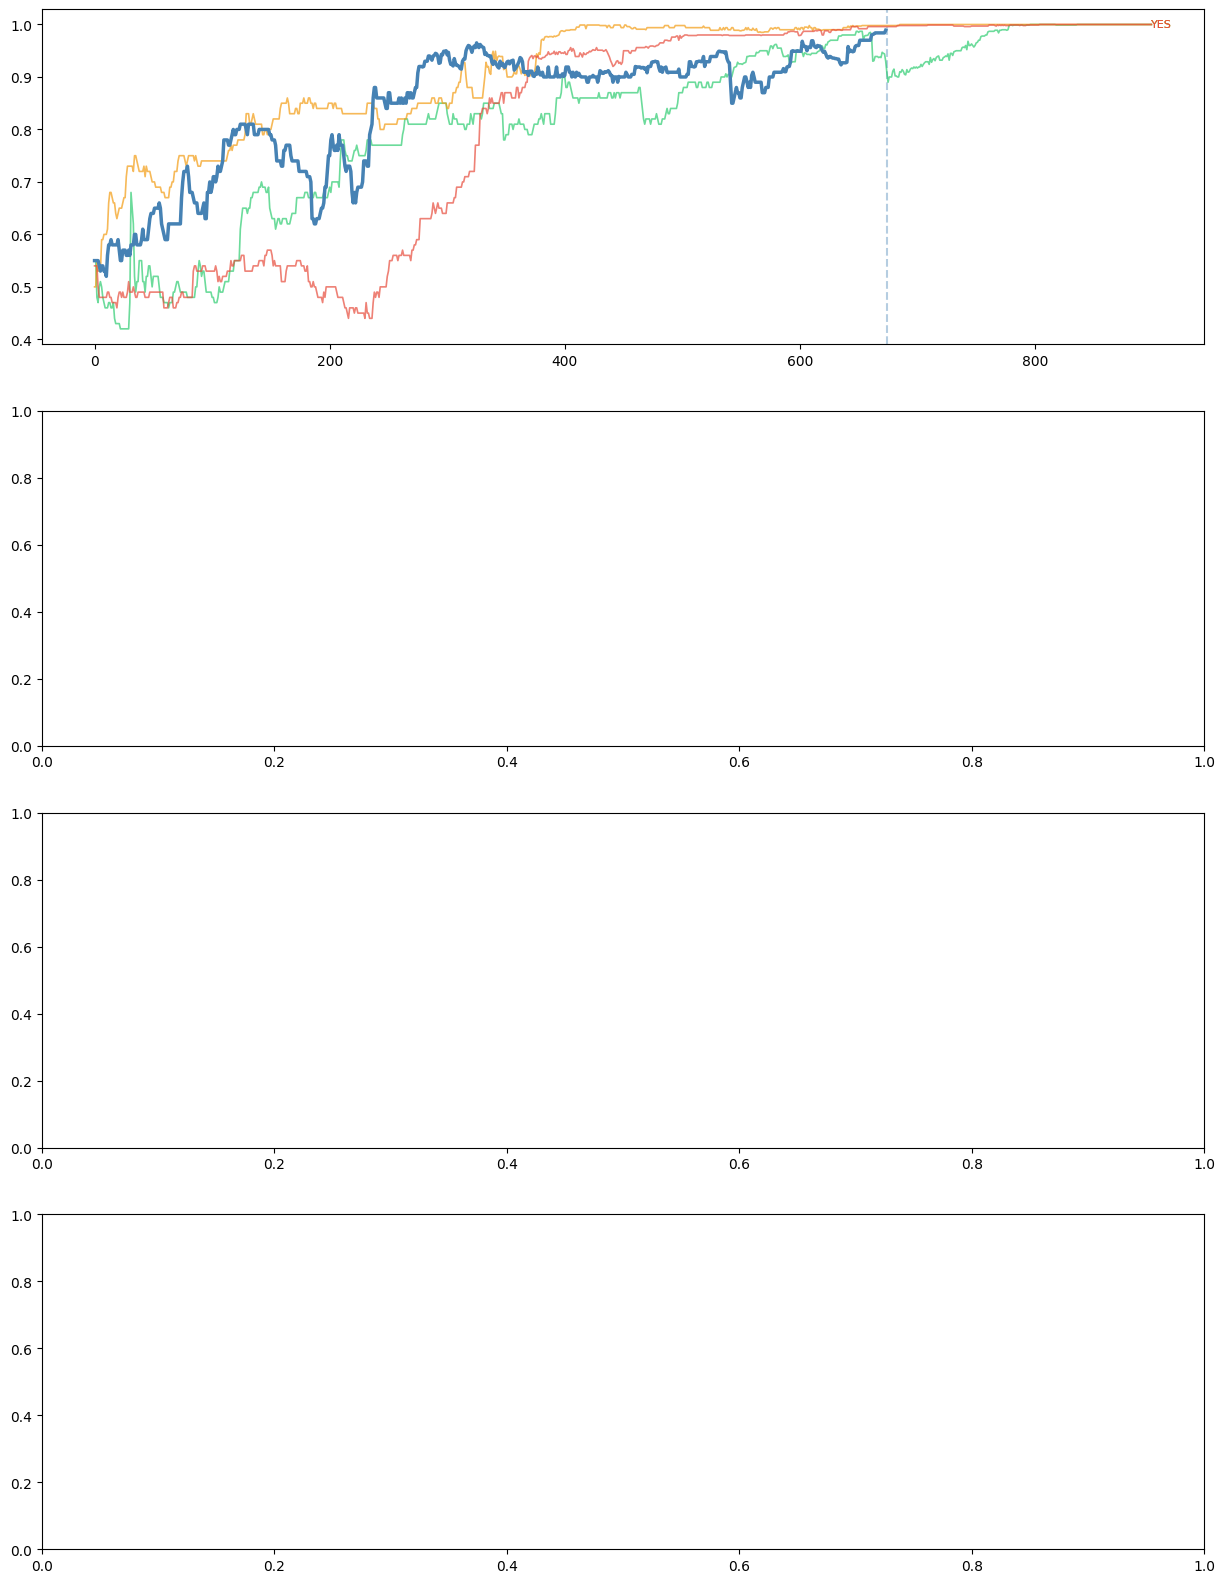

In [ ]:
import stumpy, sqlite3, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

DB  = Path.home() / ".btc_windows.db"
con = sqlite3.connect(DB)
SYMBOLS = {"BTC": "KXBTC15M", "ETH": "KXETH15M", "XRP": "KXXRP15M", "SOL": "KXSOL15M"}
# SERIES = {"KXBTC15M": "BTC", "KXETH15M": "ETH", "KXSOL15M": "SOL", "KXXRP15M": "XRP"}


# ── Current window ────────────────────────────────────────────────────────
latest_ts = con.execute(
    "SELECT MAX(window_start_ts) FROM windows"
).fetchone()[0]
T = min(int(datetime.now(timezone.utc).timestamp() - latest_ts), 897)

print(f"Current window start: {datetime.fromtimestamp(latest_ts).strftime('%H:%M')}  elapsed T={T}s")

def load_ticks(window_id, length=900):
    df = pd.read_sql(
        "SELECT elapsed_sec, yes_ask FROM ticks WHERE window_id=? ORDER BY elapsed_sec",
        con, params=(window_id,)
    )
    return (df.set_index("elapsed_sec")
              .reindex(range(length))
              .ffill().bfill()["yes_ask"]
              .to_numpy(dtype=np.float64))

def znorm_dist(a, b):
    """Z-normalised Euclidean distance between two equal-length arrays."""
    a = (a - a.mean()) / (a.std() + 1e-10)
    b = (b - b.mean()) / (b.std() + 1e-10)
    return float(np.sqrt(np.sum((a - b) ** 2)))

fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(15, 5 * len(SYMBOLS)))
COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]

for ax, (sym, prefix) in zip(axes, SYMBOLS.items()):

    # Current window ticks for this symbol
    cur_row = con.execute(
        "SELECT id FROM windows WHERE window_start_ts=? AND ticker LIKE ?",
        (latest_ts, prefix + "%")
    ).fetchone()
    if not cur_row:
        ax.set_title(f"{sym} — no current data"); continue

    cur_series = load_ticks(cur_row[0])[:T]
    if len(cur_series) < 10 or np.isnan(cur_series).all():
        ax.set_title(f"{sym} — not enough ticks yet"); continue

    # Past completed windows
    past_rows = con.execute(
        "SELECT id, window_start_ts, winner FROM windows "
        "WHERE winner IS NOT NULL AND window_start_ts < ? AND ticker LIKE ? "
        "ORDER BY window_start_ts",
        (latest_ts, prefix + "%")
    ).fetchall()

    if not past_rows:
        ax.set_title(f"{sym} — no past data"); continue

    # Compute z-norm distance between current[:T] and each past window[:T]
    candidates = []
    for wid, wts, winner in past_rows:
        past_full = load_ticks(wid)
        past_slice = past_full[:T]
        if np.isnan(past_slice).any():
            past_slice = np.nan_to_num(past_slice, nan=np.nanmean(past_slice))
        cur_clean = np.nan_to_num(cur_series, nan=np.nanmean(cur_series))
        d = znorm_dist(cur_clean, past_slice)
        candidates.append((d, wts, winner, past_full))

    candidates.sort(key=lambda x: x[0])
    top3 = candidates[:3]

    # ── Print summary ────────────────────────────────────────────────────
    print(f"\n{sym}  (current window t=0..{T})")
    print(f"  {'Rank':<5} {'Time':16} {'Outcome':>7}  {'Dist':>7}  {'Votes'}")
    outcomes = [w for _, _, w, _ in top3]
    for rank, (d, wts, winner, _) in enumerate(top3):
        t_str = datetime.fromtimestamp(wts).strftime("%m-%d %H:%M")
        print(f"  #{rank+1}    {t_str}      {winner.upper():>7}  {d:>7.3f}")
    vote_yes = outcomes.count("yes")
    vote_no  = outcomes.count("no")
    verdict  = "YES" if vote_yes > vote_no else "NO" if vote_no > vote_yes else "TIE"
    print(f"  → Stumpy vote: {verdict}  (YES={vote_yes} NO={vote_no})")

    # Current market status from latest tick
    last_tick = con.execute(
        "SELECT elapsed_sec, yes_ask, no_ask FROM ticks WHERE window_id=? "
        "ORDER BY elapsed_sec DESC LIMIT 1",
        (cur_row[0],)
    ).fetchone()
    if last_tick:
        et, ya, na = last_tick
        dominant = "YES" if (ya or 0) >= (na or 0) else "NO"
        print(f"  Current odds  t={et}s  YES={ya:.2f}  NO={na:.2f}  → market says {dominant}")

    # ── Plot ─────────────────────────────────────────────────────────────
    ax.plot(range(T), cur_series, color="steelblue", linewidth=2.5,
            label=f"Current (t=0..{T})", zorder=5)
    ax.axvline(T, color="steelblue", linestyle="--", alpha=0.4)

    for rank, (d, wts, winner, past_full) in enumerate(top3):
        t_str = datetime.fromtimestamp(wts).strftime("%m-%d %H:%M")
        lbl   = f"#{rank+1} {t_str} → {winner.upper()}  dist={d:.3f}"
        ax.plot(range(900), past_full, color=COLORS[rank], alpha=0.7,
                linewidth=1.2, label=lbl)
        # Mark outcome end
        end_val = past_full[~np.isnan(past_full)][-1]
        ax.annotate(winner.upper(), xy=(899, end_val),
                    color=COLORS[rank], fontsize=8, va="center")

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)
    ax.set_xlim(0, 900)
    ax.set_ylim(0, 1)
    ax.set_title(f"{sym} — current vs top 3 stumpy matches  |  vote → {verdict}",
                 fontweight="bold")
    ax.set_xlabel("Elapsed seconds")
    ax.set_ylabel("YES ask")
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


## Today's Orders — Win/Loss & Fees

In [677]:
import base64, os, time
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding as asym_padding
import httpx

load_dotenv(Path("/Users/Harish/highlowticker-tui/.env"), override=True)
KALSHI_BASE = "https://api.elections.kalshi.com/trade-api/v2"
_api_key     = os.environ["KALSHI_API_KEY"]
_private_key = serialization.load_pem_private_key(
    os.environ["KALSHI_API_SECRET"].encode(), password=None)

def hdrs(method, path):
    ts  = str(round(time.time() * 1000))
    msg = ts + method.upper() + path
    sig = _private_key.sign(msg.encode(),
        asym_padding.PSS(mgf=asym_padding.MGF1(hashes.SHA256()),
                         salt_length=asym_padding.PSS.MAX_LENGTH),
        hashes.SHA256())
    return {"KALSHI-ACCESS-KEY": _api_key,
            "KALSHI-ACCESS-TIMESTAMP": ts,
            "KALSHI-ACCESS-SIGNATURE": base64.b64encode(sig).decode(),
            "Content-Type": "application/json"}

# Fetch all today's fills
today = datetime.now(timezone.utc).date()
fills, cursor = [], None
with httpx.Client() as c:
    while True:
        params = {"limit": 100}
        if cursor:
            params["cursor"] = cursor
        r = c.get(f"{KALSHI_BASE}/portfolio/fills",
                  headers=hdrs("GET", "/trade-api/v2/portfolio/fills"),
                  params=params)
        data  = r.json()
        batch = data.get("fills", [])
        fills.extend(batch)
        cursor = data.get("cursor")
        if not cursor or not batch:
            break
        oldest = datetime.fromisoformat(batch[-1]["created_time"].replace("Z", "+00:00"))
        if oldest.date() < today:
            break

    fills = [f for f in fills
             if datetime.fromisoformat(f["created_time"].replace("Z", "+00:00")).date() == today]

if not fills:
    print("No fills today yet.")
else:
    with httpx.Client() as c:
        result_cache = {}
        for ticker in {f["ticker"] for f in fills}:
            r = c.get(f"{KALSHI_BASE}/markets/{ticker}",
                      headers=hdrs("GET", f"/trade-api/v2/markets/{ticker}"))
            result_cache[ticker] = r.json().get("market", {}).get("result", "open")

    rows = []
    for f in fills:
        ticker   = f["ticker"]
        side     = f["side"]
        count    = float(f.get("count_fp") or f.get("count") or 0)
        price    = float(f["yes_price_dollars"] if side == "yes" else f["no_price_dollars"])
        fee      = float(f.get("fee_cost") or f.get("fee_cost_fp") or 0)
        is_taker = f.get("is_taker", False)
        result   = result_cache.get(ticker, "open")
        cost     = price * count
        won      = (result == side)
        payout   = count if won else 0.0
        net      = round(payout - cost - fee, 3) if result != "open" else None
        ts       = datetime.fromisoformat(f["created_time"].replace("Z", "+00:00"))
        ts_et    = ts.astimezone(timezone(timedelta(hours=-4))).strftime("%H:%M:%S")
        sym      = ("BTC" if "KXBTC" in ticker else
                    "ETH" if "KXETH" in ticker else
                    "SOL" if "KXSOL" in ticker else
                    "XRP" if "KXXRP" in ticker else "?")
        rows.append({
            "time_ET": ts_et, "sym": sym, "side": side.upper(),
            "count": int(count), "price": price, "cost": round(cost, 2),
            "fee": fee, "taker": "T" if is_taker else "M",
            "result": result.upper() if result != "open" else "OPEN",
            "won": ("WIN" if won else "LOSS") if result != "open" else "\u2014",
            "net": net,
        })

    df = pd.DataFrame(rows)

    def color_won(val):
        if val == "WIN":  return "color: green; font-weight: bold"
        if val == "LOSS": return "color: red"
        return ""

    def color_net(val):
        try:
            if val is None or np.isnan(float(val)): return ""
            return "color: green" if float(val) > 0 else "color: red" if float(val) < 0 else ""
        except Exception:
            return ""

    display(
        df.style
          .map(color_won, subset=["won"])
          .map(color_net, subset=["net"])
          .format({"price": "{:.2f}", "cost": "${:.2f}", "fee": "${:.3f}",
                   "net": lambda v: f"${v:+.3f}" if v is not None else "\u2014"})
          .set_caption("Today's fills \u2014 T=taker (7% fee on profit) / M=maker (no fee)")
    )

    settled   = df[df["result"] != "OPEN"]
    wins      = settled[settled["won"] == "WIN"]
    losses    = settled[settled["won"] == "LOSS"]
    net_pnl   = settled["net"].sum()
    gross_win = wins["net"].sum()

    print(f"\nSettled: {len(settled)} fills")
    print(f"  Wins:        {len(wins)}   gross +${gross_win:.3f}")
    print(f"  Losses:      {len(losses)}   gross -${abs(losses['net'].sum()):.3f}")
    print(f"  Total cost:  ${settled['cost'].sum():.2f}")
    print(f"  Total fees:  ${settled['fee'].sum():.3f}")
    print(f"  Net P&L:     ${net_pnl:+.3f}")
    if gross_win > 0:
        print(f"  Fees/wins:   {settled['fee'].sum() / gross_win * 100:.1f}%")
    print(f"\nMaker: {(df['taker']=='M').sum()}  Taker: {(df['taker']=='T').sum()}")


,time_ET,sym,side,count,price,cost,fee,taker,result,won,net
0,13:26:16,BTC,YES,1,0.08,$0.08,$0.000,M,,LOSS,$-0.080
1,13:26:13,BTC,YES,1,0.09,$0.09,$0.000,M,,LOSS,$-0.090
2,13:26:10,XRP,YES,1,0.08,$0.08,$0.000,M,,LOSS,$-0.080
3,13:26:10,ETH,YES,1,0.02,$0.02,$0.000,M,,LOSS,$-0.020
4,13:26:09,BTC,YES,1,0.10,$0.10,$0.000,M,,LOSS,$-0.100
5,13:26:08,BTC,YES,1,0.11,$0.11,$0.000,M,,LOSS,$-0.110
6,13:26:08,BTC,YES,1,0.12,$0.12,$0.000,M,,LOSS,$-0.120
7,13:26:07,BTC,YES,1,0.13,$0.13,$0.000,M,,LOSS,$-0.130
8,13:26:07,BTC,YES,1,0.14,$0.14,$0.000,M,,LOSS,$-0.140
9,13:26:07,XRP,YES,1,0.09,$0.09,$0.000,M,,LOSS,$-0.090



Settled: 2962 fills
  Wins:        580   gross +$1147.570
  Losses:      2382   gross -$1251.700
  Total cost:  $1813.23
  Total fees:  $8.910
  Net P&L:     $-104.130
  Fees/wins:   0.8%

Maker: 2876  Taker: 86


In [ ]:
import base64, os, time
from pathlib import Path
from datetime import datetime, timezone, timedelta
from collections import defaultdict
from dotenv import load_dotenv
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding as asym_padding
import httpx
import numpy as np

load_dotenv(Path("/Users/Harish/highlowticker-tui/.env"), override=True)
KALSHI_BASE  = "https://api.elections.kalshi.com/trade-api/v2"
_api_key     = os.environ["KALSHI_API_KEY"]
_private_key = serialization.load_pem_private_key(
    os.environ["KALSHI_API_SECRET"].encode(), password=None)

def hdrs(method, path):
    ts  = str(round(time.time() * 1000))
    msg = ts + method.upper() + path
    sig = _private_key.sign(msg.encode(),
        asym_padding.PSS(mgf=asym_padding.MGF1(hashes.SHA256()),
                         salt_length=asym_padding.PSS.MAX_LENGTH),
        hashes.SHA256())
    return {"KALSHI-ACCESS-KEY": _api_key,
            "KALSHI-ACCESS-TIMESTAMP": ts,
            "KALSHI-ACCESS-SIGNATURE": base64.b64encode(sig).decode(),
            "Content-Type": "application/json"}

# ── Fetch today's fills ───────────────────────────────────────────────────────
today = datetime.now(timezone.utc).date()
fills, cursor = [], None
with httpx.Client() as c:
    while True:
        params = {"limit": 100}
        if cursor: params["cursor"] = cursor
        r = c.get(f"{KALSHI_BASE}/portfolio/fills",
                  headers=hdrs("GET", "/trade-api/v2/portfolio/fills"), params=params)
        data  = r.json()
        batch = data.get("fills", [])
        fills.extend(batch)
        cursor = data.get("cursor")
        if not cursor or not batch: break
        oldest = datetime.fromisoformat(batch[-1]["created_time"].replace("Z", "+00:00"))
        if oldest.date() < today: break

fills = [f for f in fills
         if datetime.fromisoformat(f["created_time"].replace("Z", "+00:00")).date() == today]
print(f"Total fills today: {len(fills)}")

# ── Fetch market results ──────────────────────────────────────────────────────
tickers = {f["ticker"] for f in fills}
result_cache = {}
with httpx.Client() as c:
    for ticker in tickers:
        r = c.get(f"{KALSHI_BASE}/markets/{ticker}",
                  headers=hdrs("GET", f"/trade-api/v2/markets/{ticker}"))
        if r.status_code == 200:
            result_cache[ticker] = r.json().get("market", {}).get("result", "open")
        else:
            result_cache[ticker] = "open"

# ── Group by ticker → price → fills ──────────────────────────────────────────
def win_open(ticker):
    try:
        parts = ticker.split("-")
        close = datetime.strptime(parts[1], "%d%b%y%H%M")
        return (close - timedelta(minutes=15)).strftime("%H:%M")
    except: return "?"

by_ticker = defaultdict(lambda: defaultdict(list))
for f in fills:
    ticker = f["ticker"]
    side   = f["side"]
    price  = float(f["yes_price_dollars"] if side == "yes" else f["no_price_dollars"])
    ts     = datetime.fromisoformat(f["created_time"].replace("Z","+00:00")) + timedelta(hours=-4)
    by_ticker[ticker][round(price,2)].append((ts, side))

# ── Build rows ────────────────────────────────────────────────────────────────
rows = []
for ticker, prices in by_ticker.items():
    result = result_cache.get(ticker, "open")
    for price, entries in prices.items():
        sides = {e[1] for e in entries}
        yes_t = min((e[0] for e in entries if e[1]=="yes"), default=None)
        no_t  = min((e[0] for e in entries if e[1]=="no"),  default=None)

        if "yes" in sides and "no" in sides:
            # Locked — both sides filled
            profit = round(1.0 - price * 2, 2)
            if profit <= 0: continue
            gap_s  = int(abs((yes_t - no_t).total_seconds()))
            rows.append({
                "window":  win_open(ticker),
                "ticker":  ticker,
                "price":   price,
                "YES at":  yes_t.strftime("%H:%M:%S"),
                "NO at":   no_t.strftime("%H:%M:%S"),
                "gap_s":   gap_s,
                "type":    "LOCK",
                "pnl":     profit,
            })
        elif result != "open":
            # Single side — settled
            side   = "yes" if "yes" in sides else "no"
            fill_t = yes_t if side == "yes" else no_t
            won    = (result == side)
            pnl    = round((1.0 - price) if won else -price, 2)
            rows.append({
                "window":  win_open(ticker),
                "ticker":  ticker,
                "price":   price,
                "YES at":  yes_t.strftime("%H:%M:%S") if yes_t else "—",
                "NO at":   no_t.strftime("%H:%M:%S")  if no_t  else "—",
                "gap_s":   None,
                "type":    "WIN" if won else "LOSS",
                "pnl":     pnl,
            })

df = pd.DataFrame(rows).sort_values(["window","ticker","price"], ascending=[True,True,False])

# ── Styling ───────────────────────────────────────────────────────────────────
def color_type(val):
    if val == "LOCK": return "color:#f0c040;font-weight:bold"
    if val == "WIN":  return "color:#4caf50;font-weight:bold"
    if val == "LOSS": return "color:#f44336"
    return ""

def color_pnl(val):
    try:
        v = float(val)
        if v > 0:  return "color:#4caf50;font-weight:bold"
        if v < 0:  return "color:#f44336"
    except: pass
    return ""

def bar_pnl(val):
    try:
        v = float(val)
        if v > 0: return f"background: linear-gradient(to right, #1b5e20 {min(v/1.0*100,100):.0f}%, transparent 0%)"
        if v < 0: return f"background: linear-gradient(to right, #b71c1c {min(abs(v)/0.5*100,100):.0f}%, transparent 0%)"
    except: pass
    return ""

total_locked = df[df["type"]=="LOCK"]["pnl"].sum()
total_wins   = df[df["type"]=="WIN"]["pnl"].sum()
total_losses = df[df["type"]=="LOSS"]["pnl"].sum()
net          = df["pnl"].sum()

print(f"Locked: {(df['type']=='LOCK').sum()} pairs  +${total_locked:.2f} guaranteed")
print(f"Wins:   {(df['type']=='WIN').sum()}          +${total_wins:.2f}")
print(f"Losses: {(df['type']=='LOSS').sum()}          -${abs(total_losses):.2f}")
print(f"Net P&L: ${net:+.2f}\n")




display(
    df.style
      .map(color_type, subset=["type"])
      .map(color_pnl,  subset=["pnl"])
      .apply(lambda col: col.map(bar_pnl), subset=["pnl"])
      .format({"price": "${:.2f}", "pnl": lambda v: f"+${v:.2f}" if v>0 else f"-${abs(v):.2f}",
               "gap_s": lambda v: f"{v}s" if v is not None else "—"})
      .set_caption(f"Today's fills — Net ${net:+.2f}  |  Locked +${total_locked:.2f}  |  Singles ${total_wins+total_losses:+.2f}")
)


Total fills today: 3481
Locked: 1 pairs  +$0.16 guaranteed
Wins:   2          +$1.16
Losses: 5          -$1.62
Net P&L: $-0.30



,window,ticker,price,YES at,NO at,gap_s,type,pnl
3230,01:00,KXBTC15M-26APR090115-15,$0.57,—,01:01:05,nans,LOSS,-$0.57
3231,01:00,KXBTC15M-26APR090115-15,$0.42,—,01:00:00,nans,LOSS,-$0.42
3229,01:00,KXBTC15M-26APR090115-15,$0.11,—,01:05:49,nans,LOSS,-$0.11
3233,00:30,KXBTC15M-26APR090045-45,$0.42,00:30:10,00:30:04,5.0s,LOCK,+$0.16
3232,00:30,KXBTC15M-26APR090045-45,$0.32,—,00:33:35,nans,LOSS,-$0.32
3234,00:15,KXBTC15M-26APR090030-30,$0.42,—,00:19:54,nans,WIN,+$0.58
3236,00:00,KXBTC15M-26APR090015-15,$0.42,—,00:02:50,nans,WIN,+$0.58
3235,00:00,KXBTC15M-26APR090015-15,$0.20,00:10:56,—,nans,LOSS,-$0.20


## DWT Match — Trend-Shape Similarity (vs z-norm above)

## HMM State Detection

Treats the market as one of 3 hidden states (Bearish / Uncertain / Bullish). Trains a Gaussian HMM via Baum-Welch on historical labeled windows, then runs Viterbi on the current live window. Reports current state + historical YES win rate for that state.

- **Green background** = Bullish state
- **Orange background** = Uncertain state  
- **Red background** = Bearish state
- **Yellow diamonds** = state transitions

First run trains (~60-90s). Subsequent runs use cache (instant).

In [ ]:
import sqlite3, numpy as np, pandas as pd, os, webbrowser
import plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from sklearn.cluster import KMeans
from pathlib import Path
from datetime import datetime, timezone

DB           = Path.home() / ".btc_windows.db"
SYMBOLS      = {"BTC": "KXBTC15M", "ETH": "KXETH15M", "XRP": "KXXRP15M"}
N_STATES     = 3
MAX_ITER     = 15
TOL          = 1.0
STATE_COLORS = ["#e74c3c", "#f39c12", "#2ecc71"]
STATE_NAMES  = ["Bearish", "Uncertain", "Bullish"]

# ── Feature engineering ───────────────────────────────────────────────────────

def load_ticks_hmm(con, window_id, length=900):
    df = pd.read_sql(
        "SELECT elapsed_sec, yes_ask FROM ticks WHERE window_id=? ORDER BY elapsed_sec",
        con, params=(window_id,)
    )
    arr = (df.set_index("elapsed_sec").reindex(range(length))
             .ffill().bfill()["yes_ask"].to_numpy(dtype=np.float64))
    return np.nan_to_num(arr, nan=0.5)

def make_features(arr, T):
    x     = arr[:T]
    x_sm  = pd.Series(x).rolling(15, min_periods=1).mean().to_numpy()  # 15s smooth
    delta = np.diff(x_sm, prepend=x_sm[0])
    return np.column_stack([x_sm, delta, np.abs(delta)])

# ── Core HMM functions (log-space, no underflow) ──────────────────────────────

def log_emission(obs, means, covs):
    """(T, N) log-emission matrix using diagonal Gaussians."""
    T, N = len(obs), len(means)
    log_b = np.full((T, N), -1e10)
    for k in range(N):
        try:
            rv = multivariate_normal(mean=means[k], cov=covs[k], allow_singular=True)
            p  = rv.pdf(obs)
            log_b[:, k] = np.log(np.clip(p, 1e-300, None))
        except Exception:
            pass
    return log_b

def forward(log_pi, log_A, log_b):
    T, N = log_b.shape
    alpha = np.full((T, N), -np.inf)
    alpha[0] = log_pi + log_b[0]
    for t in range(1, T):
        alpha[t] = logsumexp(alpha[t-1][:, None] + log_A, axis=0) + log_b[t]
    return alpha

def backward(log_A, log_b):
    T, N = log_b.shape
    beta = np.zeros((T, N))
    for t in range(T-2, -1, -1):
        beta[t] = logsumexp(log_A + log_b[t+1] + beta[t+1], axis=1)
    return beta

def viterbi(log_pi, log_A, log_b):
    T, N = log_b.shape
    delta = np.full((T, N), -np.inf)
    psi   = np.zeros((T, N), dtype=int)
    delta[0] = log_pi + log_b[0]
    for t in range(1, T):
        trans = delta[t-1][:, None] + log_A
        psi[t]   = trans.argmax(axis=0)
        delta[t] = trans.max(axis=0) + log_b[t]
    states = np.zeros(T, dtype=int)
    states[-1] = delta[-1].argmax()
    for t in range(T-2, -1, -1):
        states[t] = psi[t+1, states[t+1]]
    return states

# ── Baum-Welch training ───────────────────────────────────────────────────────

def train_hmm(obs_seqs, n_states=N_STATES, max_iter=MAX_ITER, tol=TOL):
    X_all = np.vstack(obs_seqs)
    D     = X_all.shape[1]

    # KMeans init for fast convergence
    km     = KMeans(n_clusters=n_states, n_init=5, random_state=42).fit(X_all)
    means  = km.cluster_centers_.copy()
    labels = km.labels_
    covs   = []
    for k in range(n_states):
        pts = X_all[labels == k]
        if len(pts) < 2:
            pts = X_all
        var = np.var(pts, axis=0)
        covs.append(np.diag(np.maximum(var, 1e-6)))
    covs = np.array(covs)

    pi = np.full(n_states, 1.0 / n_states)
    A  = np.full((n_states, n_states), 1.0 / n_states)

    prev_ll = -np.inf

    for iteration in range(max_iter):
        sum_g0   = np.zeros(n_states)
        sum_xi   = np.zeros((n_states, n_states))
        sum_g    = np.zeros(n_states)
        sum_go   = np.zeros((n_states, D))
        sum_go2  = np.zeros((n_states, D))
        total_ll = 0.0

        log_pi = np.log(pi + 1e-300)
        log_A  = np.log(A  + 1e-300)

        for obs in obs_seqs:
            log_b = log_emission(obs, means, covs)
            alpha = forward(log_pi, log_A, log_b)
            beta  = backward(log_A, log_b)
            ll    = logsumexp(alpha[-1])
            total_ll += ll

            log_gamma = alpha + beta - ll
            gamma     = np.exp(np.clip(log_gamma, -500, 0))
            gamma    /= gamma.sum(axis=1, keepdims=True) + 1e-300

            T = len(obs)
            log_xi = (alpha[:-1, :, None] + log_A[None, :, :] +
                      log_b[1:, None, :] + beta[1:, None, :] - ll)
            xi = np.exp(np.clip(log_xi, -500, 0))
            xi /= xi.sum(axis=(1, 2), keepdims=True) + 1e-300

            sum_g0  += gamma[0]
            sum_xi  += xi.sum(axis=0)
            sum_g   += gamma.sum(axis=0)
            sum_go  += gamma.T @ obs
            sum_go2 += gamma.T @ (obs ** 2)

        # M-step
        pi    = sum_g0 / (sum_g0.sum() + 1e-300)
        A     = sum_xi / (sum_xi.sum(axis=1, keepdims=True) + 1e-300)
        means = sum_go / (sum_g[:, None] + 1e-300)
        var   = sum_go2 / (sum_g[:, None] + 1e-300) - means ** 2
        covs  = np.array([np.diag(np.maximum(var[k], 1e-6)) for k in range(n_states)])

        if abs(total_ll - prev_ll) < tol:
            print(f"  converged at iter {iteration+1}  ll={total_ll:.1f}")
            break
        prev_ll = total_ll

    # Relabel: state 0=Bearish (lowest yes_ask), state 2=Bullish
    order = np.argsort(means[:, 0])
    means = means[order]; covs = covs[order]
    pi    = pi[order];    A    = A[np.ix_(order, order)]

    return {"pi": pi, "A": A, "means": means, "covs": covs}

# ── Module-level cache ────────────────────────────────────────────────────────

try: _HMM_CACHE
except NameError: _HMM_CACHE = {}

# ── Main ──────────────────────────────────────────────────────────────────────

con_hmm   = sqlite3.connect(DB)
latest_ts = con_hmm.execute("SELECT MAX(window_start_ts) FROM windows").fetchone()[0]
T         = min(int(datetime.now(timezone.utc).timestamp() - latest_ts), 897)
print(f"Window: {datetime.fromtimestamp(latest_ts).strftime('%H:%M ET')}  t={T}s\n")

results = {}

for sym, prefix in SYMBOLS.items():
    print(f"── {sym} ──────────────────────────────────────────")

    # Training data
    rows = con_hmm.execute(
        "SELECT w.id, w.winner FROM windows w "
        "WHERE w.winner IS NOT NULL AND w.ticker LIKE ? "
        "AND (SELECT COUNT(*) FROM ticks WHERE window_id=w.id) > 100 "
        "ORDER BY w.window_start_ts",
        (prefix + "%",)
    ).fetchall()
    n_labeled = len(rows)

    if n_labeled < 5:
        print(f"  Not enough labeled windows ({n_labeled}), skipping"); continue

    # Train or reuse cached model
    if sym not in _HMM_CACHE or _HMM_CACHE[sym]["n_windows"] != n_labeled:
        print(f"  Training HMM on {n_labeled} windows...")
        obs_seqs = []
        for wid, _ in rows:
            arr  = load_ticks_hmm(con_hmm, wid)
            feat = make_features(arr, 900)
            obs_seqs.append(feat)
        model = train_hmm(obs_seqs)
        model["n_windows"] = n_labeled

        # Per-state win rates
        log_pi = np.log(model["pi"] + 1e-300)
        log_A  = np.log(model["A"]  + 1e-300)
        state_yes = np.zeros(N_STATES)
        state_no  = np.zeros(N_STATES)
        for (wid, winner), obs in zip(rows, obs_seqs):
            log_b = log_emission(obs, model["means"], model["covs"])
            sts   = viterbi(log_pi, log_A, log_b)
            dom   = np.bincount(sts, minlength=N_STATES).argmax()
            if winner == "yes": state_yes[dom] += 1
            else:               state_no[dom]  += 1
        model["win_rates"] = state_yes / (state_yes + state_no + 1e-10)
        model["state_counts"] = (state_yes + state_no).astype(int)
        _HMM_CACHE[sym] = model
        print(f"  Trained. Win rates: " +
              "  ".join(f"{STATE_NAMES[k]}={model['win_rates'][k]:.0%}({model['state_counts'][k]})"
                        for k in range(N_STATES)))
    else:
        model = _HMM_CACHE[sym]
        print(f"  Cached ({n_labeled} windows). Win rates: " +
              "  ".join(f"{STATE_NAMES[k]}={model['win_rates'][k]:.0%}({model['state_counts'][k]})"
                        for k in range(N_STATES)))

    # Live window
    cur = con_hmm.execute(
        "SELECT id FROM windows WHERE window_start_ts=? AND ticker LIKE ?",
        (latest_ts, prefix + "%")
    ).fetchone()
    if not cur or T < 16:
        print("  No live data yet"); continue

    arr    = load_ticks_hmm(con_hmm, cur[0])
    feat   = make_features(arr, T)
    log_pi = np.log(model["pi"] + 1e-300)
    log_A  = np.log(model["A"]  + 1e-300)
    log_b  = log_emission(feat, model["means"], model["covs"])
    states = viterbi(log_pi, log_A, log_b)

    cur_state   = states[-1]
    win_rate    = model["win_rates"][cur_state]
    transitions = np.where(np.diff(states))[0] + 1

    print(f"  Current state: [{cur_state}] {STATE_NAMES[cur_state]}  "
          f"→ YES rate {win_rate:.0%}")
    print(f"  Transitions at t: {transitions.tolist()}")
    print(f"  Transition matrix A:\n" +
          "\n".join(f"    {STATE_NAMES[i]:10s} → " +
                    "  ".join(f"{STATE_NAMES[j]}:{model['A'][i,j]:.2f}" for j in range(N_STATES))
                    for i in range(N_STATES)))

    cur_yes_ask = arr[T-1] if T > 0 else 0.5
  cur_no_ask  = round(1.0 - cur_yes_ask, 2)

  # Divergence alert: state and price point in opposite directions
  alert = ""
  if cur_state == 0 and cur_yes_ask >= 0.55:   # Bearish but price elevated → buy NO
      implied_edge = round((win_rate < 0.45) and (1.0 - cur_yes_ask) or 0, 2)
      payout = round(1.0 / cur_no_ask, 2) if cur_no_ask > 0 else 0
      alert = (f"  *** EDGE: buy NO @ {cur_no_ask:.2f}  "
               f"payout={payout:.1f}x  model says {1-win_rate:.0%} NO chance")
  elif cur_state == 2 and cur_yes_ask <= 0.45:  # Bullish but price depressed → buy YES
      payout = round(1.0 / cur_yes_ask, 2) if cur_yes_ask > 0 else 0
      alert = (f"  *** EDGE: buy YES @ {cur_yes_ask:.2f}  "
               f"payout={payout:.1f}x  model says {win_rate:.0%} YES chance")

  if alert:
      print(alert)

  results[sym] = {"arr": arr, "states": states, "win_rates": model["win_rates"],
                    "cur_state": cur_state, "cur_yes_ask": cur_yes_ask, "alert": alert}

# ── Plotly ────────────────────────────────────────────────────────────────────

syms_done = [s for s in SYMBOLS if s in results]
if syms_done:
    n = len(syms_done)
    fig = make_subplots(rows=n, cols=1,
                        subplot_titles=syms_done,
                        vertical_spacing=0.08)

    for row_idx, sym in enumerate(syms_done, 1):
        r          = results[sym]
        arr        = r["arr"]
        states     = r["states"]
        cur_state  = r["cur_state"]
        win_rate   = r["win_rates"][cur_state]
        cur_ya     = r["cur_yes_ask"]
        edge_tag   = "  *** EDGE" if r["alert"] else ""
        title_str  = (f"{sym} — {STATE_NAMES[cur_state]}  "
                      f"YES rate: {win_rate:.0%}  yes_ask={cur_ya:.2f}  t={T}s{edge_tag}")
        fig.layout.annotations[row_idx-1].text = title_str

        # Colored state background
        boundaries = np.concatenate([[0], np.where(np.diff(states))[0] + 1, [len(states)]])
        for i in range(len(boundaries) - 1):
            s0, s1 = boundaries[i], boundaries[i+1]
            k = states[s0]
            fig.add_shape(
                type="rect",
                x0=int(s0), x1=int(s1), y0=0, y1=1,
                yref="y domain",
                fillcolor=STATE_COLORS[k], opacity=0.35,
                line_width=0, layer="below",
                row=row_idx, col=1
            )

        # yes_ask price line
        fig.add_trace(go.Scatter(
            x=list(range(T)), y=arr[:T].tolist(),
            mode="lines", name=f"{sym} yes_ask",
            line=dict(color="white", width=2),
            showlegend=(row_idx == 1),
        ), row=row_idx, col=1)

        # Transition markers
        trans_idx = np.where(np.diff(states))[0] + 1
        if len(trans_idx):
            fig.add_trace(go.Scatter(
                x=trans_idx.tolist(), y=arr[trans_idx].tolist(),
                mode="markers", name="Transition",
                marker=dict(color="yellow", size=9, symbol="diamond"),
                showlegend=(row_idx == 1),
            ), row=row_idx, col=1)

        # 0.5 reference
        fig.add_hline(y=0.5, line_dash="dot", line_color="gray",
                      opacity=0.4, row=row_idx, col=1)

        cur_state = r["cur_state"]
        win_rate  = r["win_rates"][cur_state]
        fig.layout.annotations[row_idx - 1].text = (
            f"{sym} — {STATE_NAMES[cur_state]}  YES rate: {win_rate:.0%}  t={T}s"
        )

    # State legend traces (invisible, for legend only)
    for k in range(N_STATES):
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode="markers",
            marker=dict(color=STATE_COLORS[k], size=12, symbol="square"),
            name=STATE_NAMES[k], showlegend=True,
        ), row=1, col=1)

    fig.update_yaxes(range=[0, 1], tickformat=".2f")
    fig.update_xaxes(range=[0, 900], title_text="Elapsed seconds")
    fig.update_layout(
        height=400 * n,
        template="plotly_dark",
        title_text=f"HMM States — {datetime.fromtimestamp(latest_ts).strftime('%H:%M ET')}  t={T}s",
        legend=dict(orientation="v", x=1.01, y=1),
        hovermode="x unified",
    )

    html_path = os.path.expanduser("~/hmm_states.html")
    pio.write_html(fig, html_path)
    webbrowser.open(f"file://{html_path}")
    print(f"\nChart saved: {html_path}")
else:
    print("No results to plot.")


## Lagging Coin Analysis — Does the Straggler Catch Up?

In [ ]:
import sqlite3, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DB  = Path.home() / ".btc_windows.db"
con = sqlite3.connect(DB)

SERIES   = {"KXBTC15M": "BTC", "KXETH15M": "ETH", "KXXRP15M": "XRP"}
SYMS     = list(SERIES.values())
LAG_MIN  = 0.10   # lagging coin must be at least 10% lower than avg of others
LEAD_MIN = 0.60   # the two leading coins must both be above this
ENTRY_T  = (30, 600)  # only look at seconds 30–600 (early–mid window)

# ── Load all resolved windows with full tick data ─────────────────────────
windows = pd.read_sql("""
    SELECT w.id, w.window_start_ts, w.winner,
           CASE
             WHEN w.ticker LIKE 'KXBTC%' THEN 'BTC'
             WHEN w.ticker LIKE 'KXETH%' THEN 'ETH'
             WHEN w.ticker LIKE 'KXXRP%' THEN 'XRP'
           END as sym
    FROM windows w
    WHERE w.winner IS NOT NULL
      AND (w.ticker LIKE 'KXBTC15M%' OR w.ticker LIKE 'KXETH15M%' OR w.ticker LIKE 'KXXRP15M%')
    ORDER BY w.window_start_ts
""", con)

# Only windows where ALL 3 symbols resolved
full_windows = (
    windows.groupby("window_start_ts")
           .filter(lambda g: set(g["sym"]) == set(SYMS))
)
window_ts_list = full_windows["window_start_ts"].unique()
print(f"Windows with all 3 symbols resolved: {len(window_ts_list)}")

# ── For each window, scan ticks second-by-second for lag pattern ──────────
hits = []

for wts in window_ts_list:
    grp = full_windows[full_windows["window_start_ts"] == wts]
    # Load ticks for each sym
    tick_data = {}
    outcomes  = {}
    for _, row in grp.iterrows():
        df = pd.read_sql(
            "SELECT elapsed_sec, yes_ask, no_ask FROM ticks WHERE window_id=? ORDER BY elapsed_sec",
            con, params=(int(row["id"]),)
        )
        tick_data[row["sym"]] = df.set_index("elapsed_sec")
        outcomes[row["sym"]]  = row["winner"]

    # Merge on elapsed_sec
    merged = pd.concat(
        {s: tick_data[s] for s in SYMS if s in tick_data},
        axis=1
    ).dropna(how="all")

    # For each second in ENTRY_T range, check lag pattern
    for t in range(ENTRY_T[0], ENTRY_T[1] + 1):
        if t not in merged.index:
            continue
        row_t = merged.loc[t]

        # high_side and high_prob per sym
        probs = {}
        sides = {}
        for s in SYMS:
            try:
                ya = float(row_t[(s, "yes_ask")] or 0)
                na = float(row_t[(s, "no_ask")]  or 0)
            except Exception:
                ya, na = 0, 0
            if ya <= 0 or na <= 0:
                break
            if ya >= na:
                probs[s], sides[s] = ya, "yes"
            else:
                probs[s], sides[s] = na, "no"
        else:
            # All 3 valid — check alignment
            if len(set(sides.values())) != 1:
                continue  # mixed direction

            dominant = next(iter(sides.values()))
            prob_vals = list(probs.values())
            avg_prob  = np.mean(prob_vals)
            min_sym   = min(probs, key=probs.get)
            min_prob  = probs[min_sym]
            others_avg= np.mean([probs[s] for s in SYMS if s != min_sym])

            lag = others_avg - min_prob
            if lag < LAG_MIN:
                continue  # not lagging enough

            # Both leading coins must be above LEAD_MIN
            leader_probs = [probs[s] for s in SYMS if s != min_sym]
            if any(p < LEAD_MIN for p in leader_probs):
                continue  # leaders not strong enough

            # What price would we buy the lagging coin at?
            entry_price = min_prob  # buying the dominant side at this price
            entry_side  = dominant
            outcome     = outcomes.get(min_sym, "")
            won         = (outcome == entry_side)
            pnl         = (1.0 - entry_price) if won else -entry_price

            hits.append({
                "window_ts":   wts,
                "t":           t,
                "lag_sym":     min_sym,
                "lag_prob":    round(min_prob, 3),
                "others_avg":  round(others_avg, 3),
                "lag":         round(lag, 3),
                "side":        entry_side,
                "outcome":     outcome,
                "won":         won,
                "pnl":         round(pnl, 3),
            })

df_hits = pd.DataFrame(hits)
if df_hits.empty:
    print("No lag patterns found — try lowering LAG_MIN")
else:
    print(f"\nTotal lag instances found: {len(df_hits)}")
    print(f"Unique windows with a lag: {df_hits['window_ts'].nunique()}")

    # ── Summary by lagging coin ────────────────────────────────────────
    print("\n── By lagging coin ──────────────────────────────────────")
    by_sym = df_hits.groupby("lag_sym").agg(
        instances =("won", "count"),
        wins      =("won", "sum"),
        win_pct   =("won", "mean"),
        avg_entry =("lag_prob", "mean"),
        avg_lag   =("lag", "mean"),
        total_pnl =("pnl", "sum"),
        avg_pnl   =("pnl", "mean"),
    ).round(3)
    by_sym["win_pct"] = (by_sym["win_pct"] * 100).round(1)
    print(by_sym.to_string())

    # ── Summary by time bucket ─────────────────────────────────────────
    print("\n── By time bucket (when lag detected) ───────────────────")
    df_hits["t_bucket"] = (df_hits["t"] // 60) * 60
    by_t = df_hits.groupby("t_bucket").agg(
        instances=("won", "count"),
        win_pct  =("won", lambda x: f"{x.mean()*100:.1f}%"),
        avg_entry=("lag_prob", "mean"),
        avg_pnl  =("pnl", "mean"),
    ).round(3)
    print(by_t.to_string())

    # ── Best entry moments (highest win rate, enough samples) ──────────
    good = df_hits.groupby(["lag_sym", "t_bucket"]).agg(
        n      =("won", "count"),
        win_pct=("won", "mean"),
        avg_pnl=("pnl", "mean"),
    ).reset_index()
    good = good[good["n"] >= 3].sort_values("win_pct", ascending=False)
    if not good.empty:
        print("\n── Best (sym, time) combos (n≥3) ────────────────────────")
        good["win_pct"] = (good["win_pct"] * 100).round(1)
        good["avg_pnl"] = good["avg_pnl"].round(3)
        print(good.head(10).to_string(index=False))

    # ── Plot: win rate vs lag magnitude ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for sym, grp in df_hits.groupby("lag_sym"):
        axes[0].scatter(grp["lag"], grp["pnl"], alpha=0.4, label=sym, s=15)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_xlabel("Lag size (others_avg − lag_prob)")
    axes[0].set_ylabel("P&L per share")
    axes[0].set_title("P&L vs Lag Size")
    axes[0].legend()

    # Win rate by time bucket overall
    tb = df_hits.groupby("t_bucket")["won"].mean() * 100
    axes[1].bar(tb.index, tb.values, width=50, color="steelblue", alpha=0.8)
    axes[1].axhline(50, color="red", linestyle="--", linewidth=0.8, label="50% breakeven")
    axes[1].set_xlabel("Window elapsed seconds")
    axes[1].set_ylabel("Win rate %")
    axes[1].set_title("Win Rate by Time of Detection")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\nOverall: {len(df_hits)} instances  "
          f"win rate={df_hits['won'].mean()*100:.1f}%  "
          f"avg P&L per share={df_hits['pnl'].mean():.3f}  "
          f"total P&L={df_hits['pnl'].sum():.2f}")
    breakeven = 1 / (1 + df_hits["lag_prob"].mean())
    print(f"Breakeven win rate at avg entry {df_hits['lag_prob'].mean():.2f}: {breakeven*100:.1f}%")
